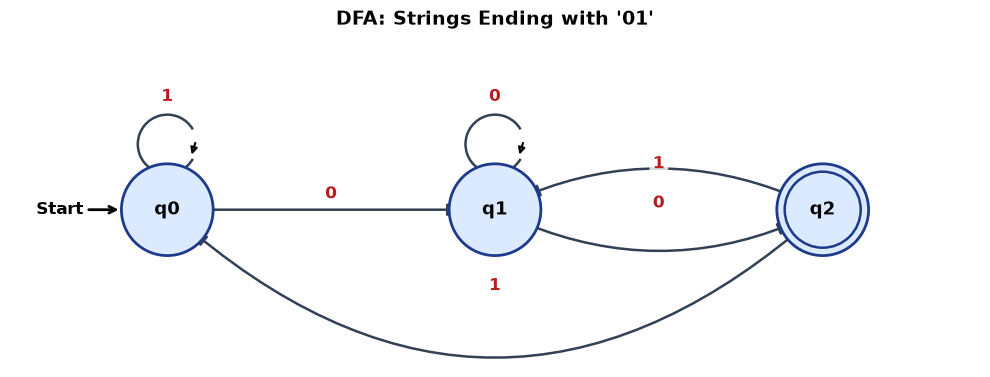


--- Simulation Result ---
Input string : 1001
Path taken   : q0 -> q0 -> q1 -> q1 -> q2
Status       : ACCEPTED ✅


In [2]:
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np


class DFA:

  def __init__(
      self, states, alphabet, transition_function, start_state, accept_states
  ):
    self.states = list(states)
    self.alphabet = set(alphabet)
    self.transition_function = transition_function
    self.start_state = start_state
    self.accept_states = set(accept_states)

  def trace(self, input_string):
    current_state = self.start_state
    path = [current_state]
    for symbol in input_string:
      if symbol not in self.alphabet:
        return False, path
      current_state = self.transition_function[current_state][symbol]
      path.append(current_state)
    return current_state in self.accept_states, path

  def visualize_matplotlib(self, test_string=None):
    fig, ax = plt.subplots(figsize=(10, 5))

    # 1. Clean horizontal layout
    pos = {"q0": np.array([1.0, 2.0]), "q1": np.array([3.5, 2.0]), "q2": np.array([6.0, 2.0])}
    r = 0.35  # Node radius

    # 2. Draw states
    for state, (x, y) in pos.items():
      # Outer circle
      circle = plt.Circle(
          (x, y),
          r,
          facecolor="#dbeafe",
          edgecolor="#1e3a8a",
          linewidth=2,
          zorder=3,
      )
      ax.add_patch(circle)

      # Accept state double ring
      if state in self.accept_states:
        inner_circle = plt.Circle(
            (x, y),
            r - 0.06,
            facecolor="#dbeafe",
            edgecolor="#1e3a8a",
            linewidth=1.8,
            zorder=4,
        )
        ax.add_patch(inner_circle)

      # State text
      ax.text(
          x,
          y,
          state,
          ha="center",
          va="center",
          fontsize=13,
          fontweight="bold",
          zorder=5,
      )

    # 3. Start state arrow
    sx, sy = pos[self.start_state]
    ax.annotate(
        "Start",
        xy=(sx - r, sy),
        xytext=(sx - 1.0, sy),
        arrowprops=dict(facecolor="black", arrowstyle="->", lw=2),
        fontsize=12,
        fontweight="bold",
        va="center",
    )

    # 4. Draw transitions with distinct curved arcs
    # (src, dst, label, curvature_rad, label_offset_y)
    transitions_to_draw = [
        # q0 transitions
        ("q0", "q1", "0", 0.0, 0.12),
        # q1 transitions
        ("q1", "q2", "1", 0.25, 0.15),
        # q2 transitions
        ("q2", "q1", "0", 0.25, -0.15),
        ("q2", "q0", "1", -0.45, -0.22),
    ]

    for src, dst, label, rad, lbl_off in transitions_to_draw:
      p1 = pos[src]
      p2 = pos[dst]

      # Draw curved arrow
      arrow = patches.FancyArrowPatch(
          posA=(p1[0], p1[1]),
          posB=(p2[0], p2[1]),
          connectionstyle=f"arc3,rad={rad}",
          arrowstyle="-|>",
          mutation_scale=18,
          color="#334155",
          lw=1.8,
          shrinkA=r * 72,
          shrinkB=r * 72,
          zorder=2,
      )
      ax.add_patch(arrow)

      # Position label along the arc
      mid_x = (p1[0] + p2[0]) / 2
      mid_y = (p1[1] + p2[1]) / 2 + (rad * 0.8) + lbl_off
      ax.text(
          mid_x,
          mid_y,
          label,
          fontsize=12,
          fontweight="bold",
          color="#b91c1c",
          ha="center",
          va="center",
          bbox=dict(
              boxstyle="round,pad=0.2",
              facecolor="white",
              edgecolor="none",
              alpha=0.8,
          ),
      )

    # 5. Self-loops (q0 on '1', q1 on '0')
    self_loops = [("q0", "1"), ("q1", "0")]
    for state, label in self_loops:
      x, y = pos[state]
      loop = patches.Arc(
          (x, y + r + 0.15),
          0.45,
          0.45,
          angle=0,
          theta1=30,
          theta2=330,
          color="#334155",
          lw=1.8,
      )
      ax.add_patch(loop)
      # Arrowhead on self loop
      ax.annotate(
          "",
          xy=(x + 0.18, y + r + 0.05),
          xytext=(x + 0.22, y + r + 0.18),
          arrowprops=dict(facecolor="#334155", arrowstyle="-|>", lw=1.5),
      )
      # Label above loop
      ax.text(
          x,
          y + r + 0.48,
          label,
          fontsize=12,
          fontweight="bold",
          color="#b91c1c",
          ha="center",
      )

    ax.set_xlim(-0.2, 7.2)
    ax.set_ylim(0.8, 3.2)
    ax.set_aspect("equal")
    plt.title(
        "DFA: Strings Ending with '01'", fontsize=14, fontweight="bold", pad=20
    )
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    # Trace output
    if test_string is not None:
      accepted, path = self.trace(test_string)
      verdict = "ACCEPTED ✅" if accepted else "REJECTED ❌"
      print(f"\n--- Simulation Result ---")
      print(f"Input string : {test_string}")
      print(f"Path taken   : {' -> '.join(path)}")
      print(f"Status       : {verdict}")


# --- Execution ---
states = {"q0", "q1", "q2"}
alphabet = {"0", "1"}
start_state = "q0"
accept_states = {"q2"}
transitions = {
    "q0": {"0": "q1", "1": "q0"},
    "q1": {"0": "q1", "1": "q2"},
    "q2": {"0": "q1", "1": "q0"},
}

dfa = DFA(states, alphabet, transitions, start_state, accept_states)
dfa.visualize_matplotlib(test_string="1001")